In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

In [2]:
from pathlib import Path
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

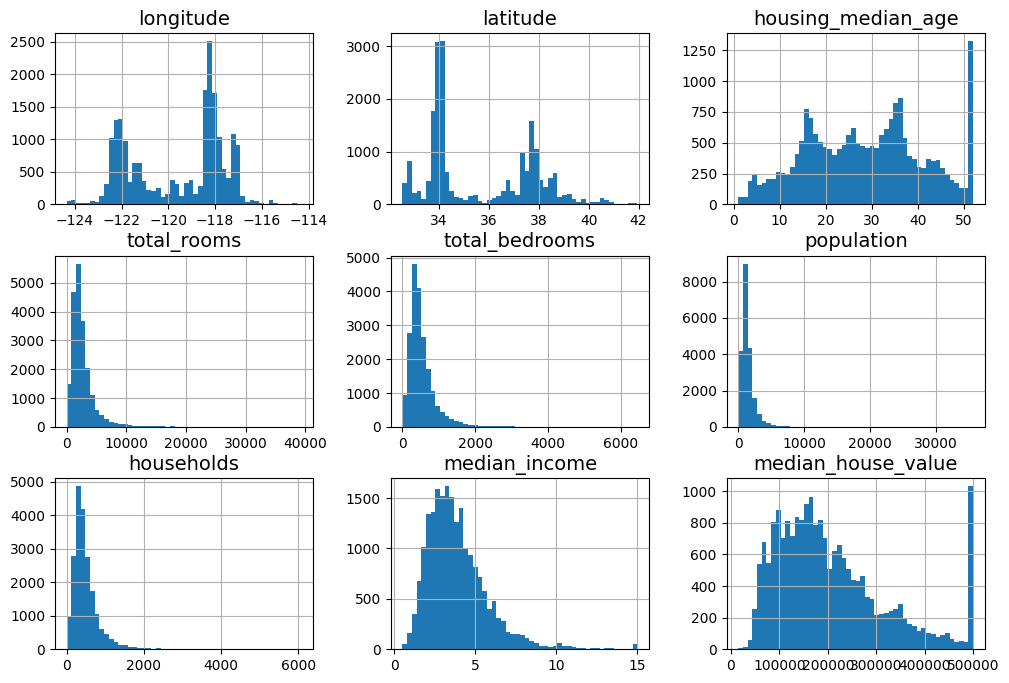

In [3]:
# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing_full.hist(bins=50, figsize=(12, 8))

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

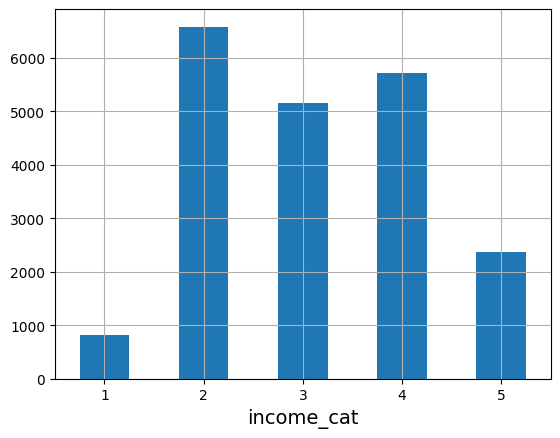

In [7]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"], bins=[0.0, 1.5, 3.0,4.0,6,np.inf], labels=[1,2,3,4,5])

cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.show()



In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full, housing_full["income_cat"]):
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n = housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [10]:
strat_train_set, strat_test_set = train_test_split(housing_full, test_size=0.2, stratify=housing_full["income_cat"], random_state=42)

for set_ in strat_test_set, strat_train_set:
    set_.drop("income_cat", axis=1, inplace = True)

In [12]:
housing = strat_train_set.copy()
type(housing)

pandas.core.frame.DataFrame

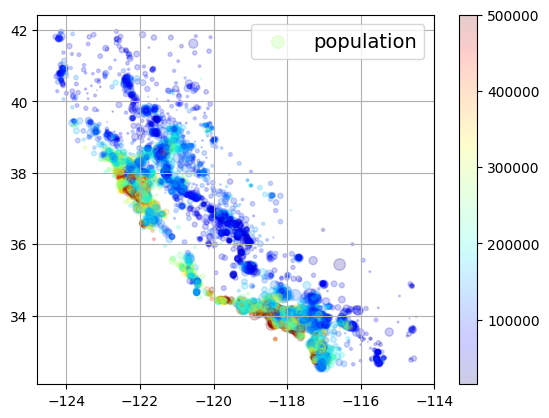

In [ ]:
plt.scatter(housing["longitude"], housing["latitude"], alpha=0.2, s=housing["population"]/100, label="population",
             c=housing["median_house_value"], cmap="jet")
plt.grid(True)
plt.legend()
plt.colorbar()
plt.show()

In [24]:
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix)

                    longitude  latitude  ...  median_income  median_house_value
longitude            1.000000 -0.924690  ...      -0.012489           -0.047602
latitude            -0.924690  1.000000  ...      -0.081392           -0.142427
housing_median_age  -0.106634  0.010060  ...      -0.121060            0.102871
total_rooms          0.046018 -0.037122  ...       0.199211            0.139039
total_bedrooms       0.069974 -0.067512  ...      -0.011382            0.050914
population           0.106253 -0.115703  ...       0.001029           -0.025161
households           0.056115 -0.072306  ...       0.008830            0.067247
median_income       -0.012489 -0.081392  ...       1.000000            0.687720
median_house_value  -0.047602 -0.142427  ...       0.687720            1.000000

[9 rows x 9 columns]


<Figure size 500x500 with 0 Axes>

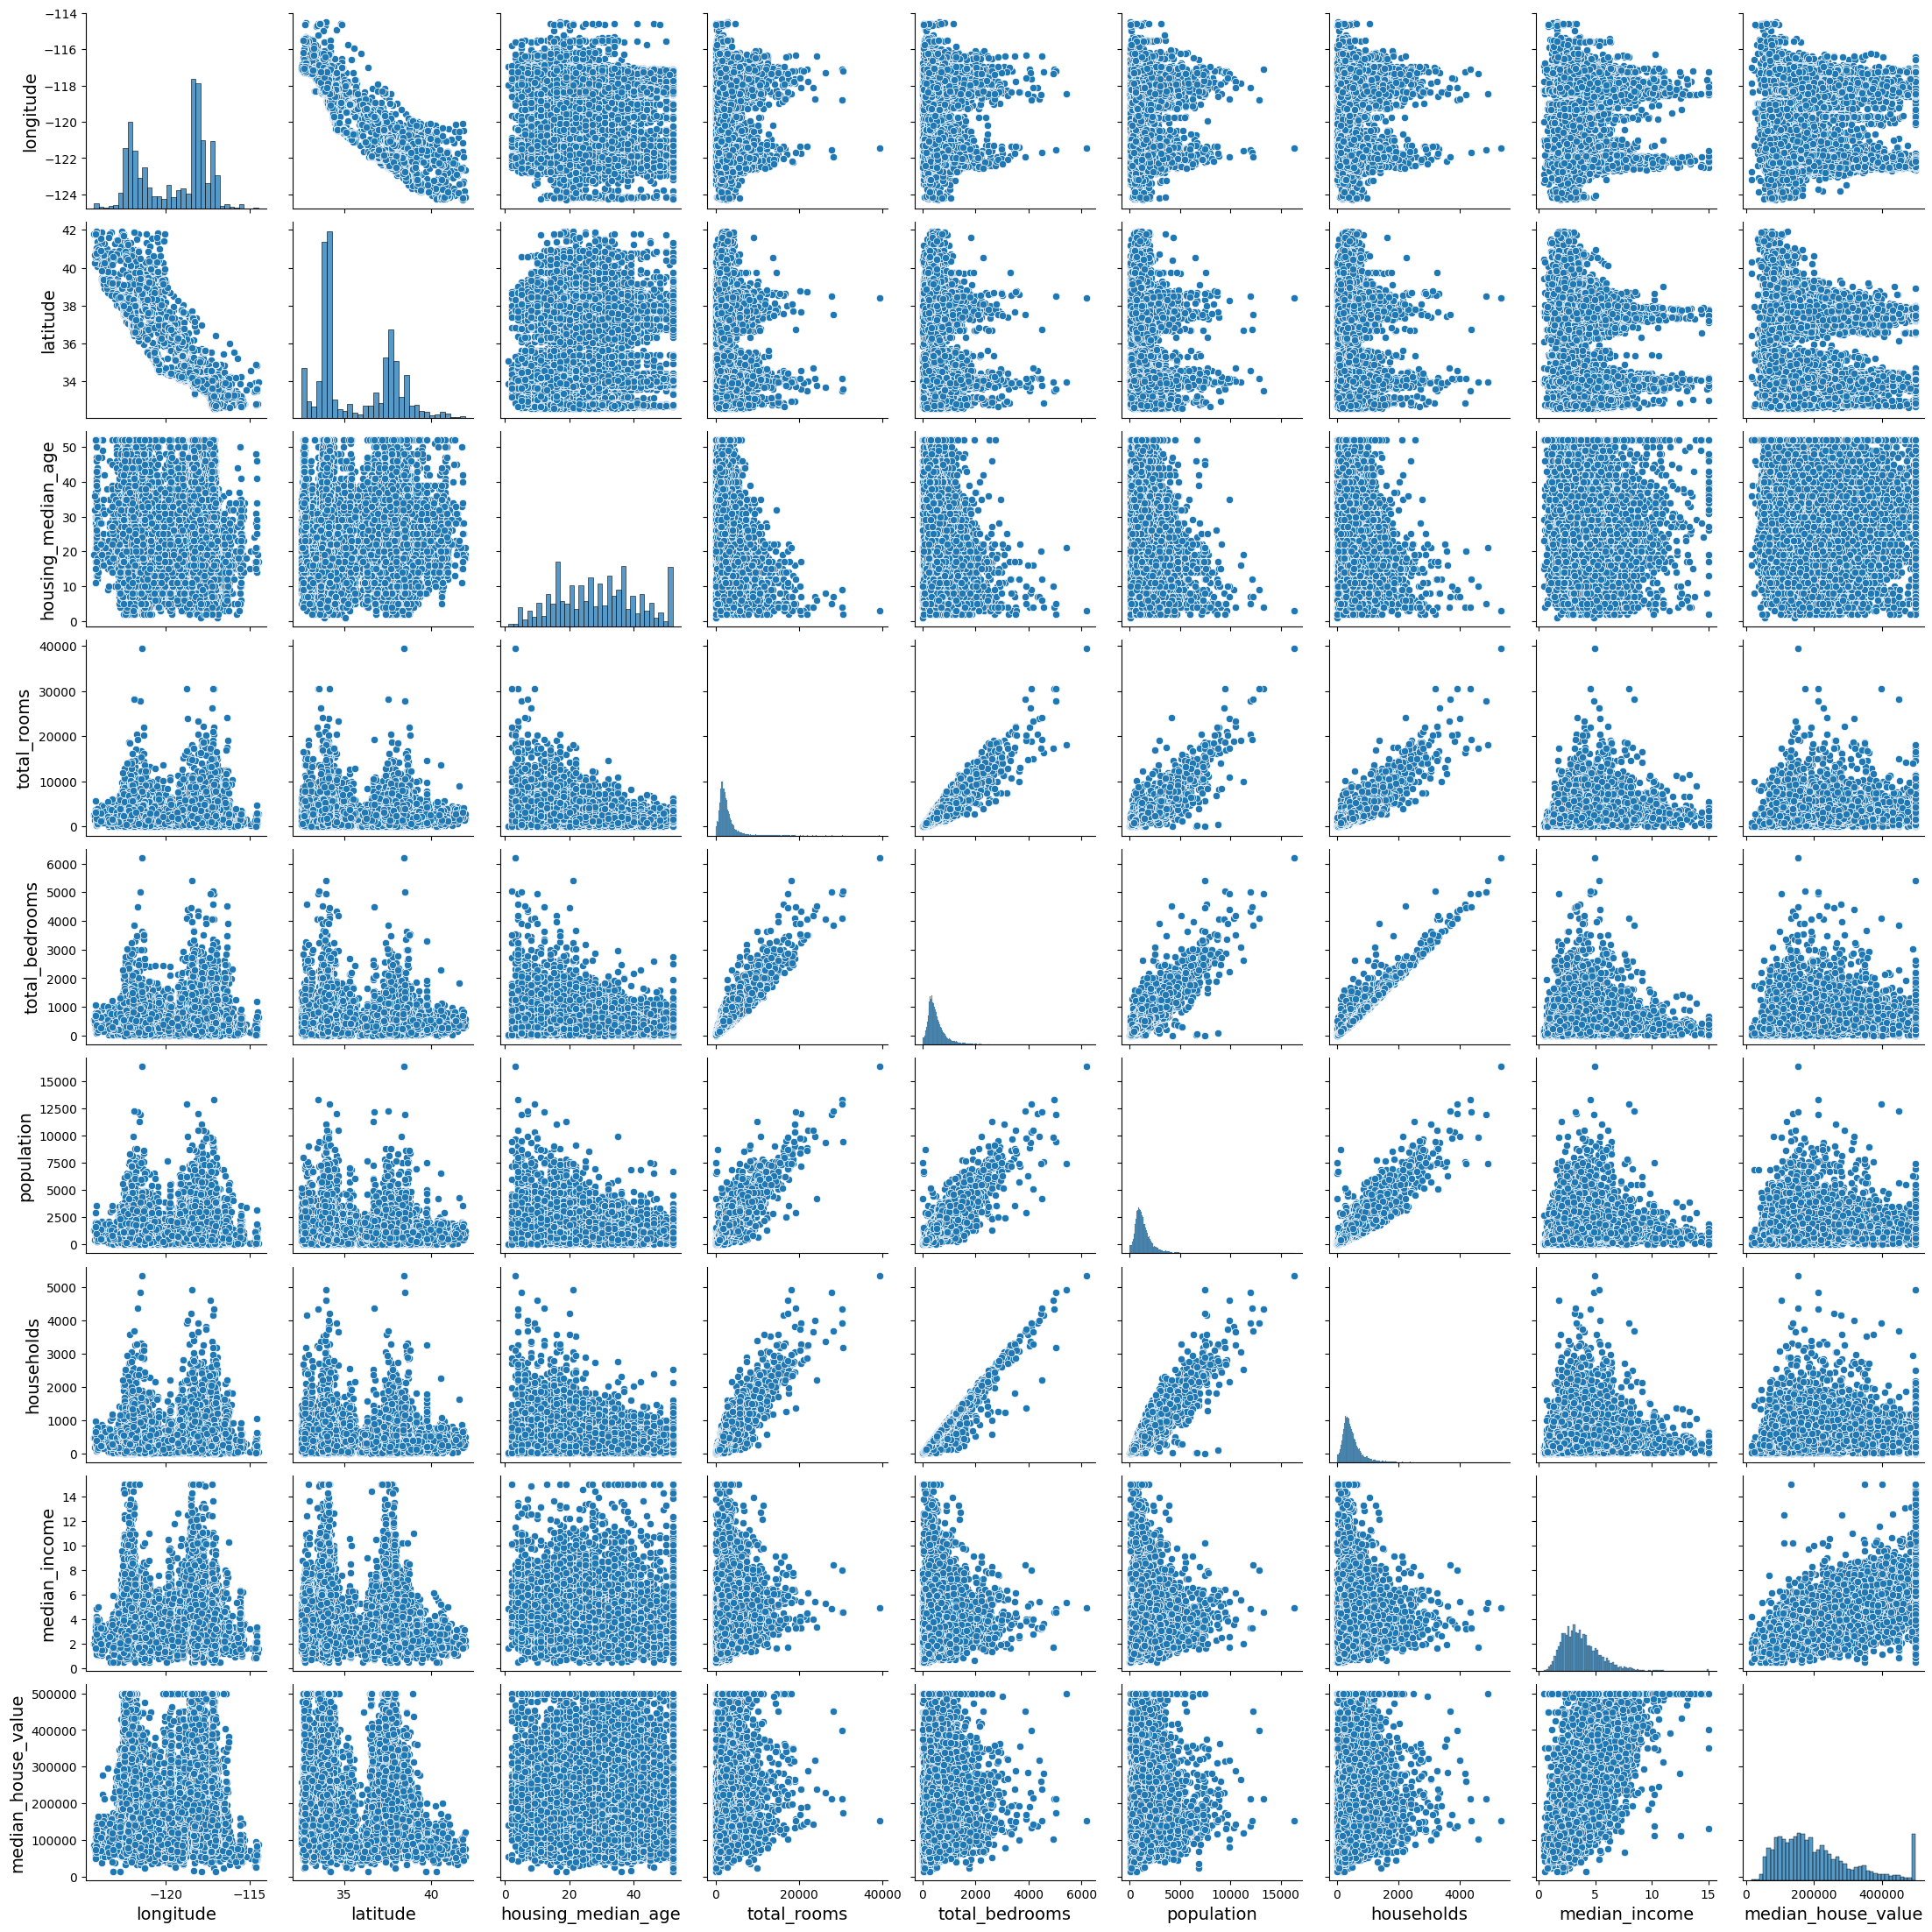

In [32]:
from seaborn import pairplot
plt.figure(figsize=(5,5))
pairplot(housing)


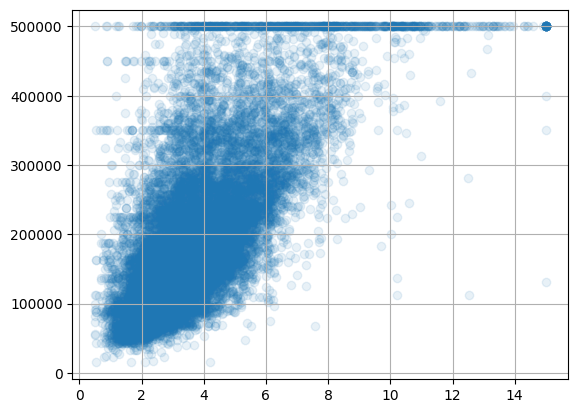

In [33]:
plt.scatter(housing["median_income"], housing["median_house_value"], alpha=0.1)
plt.grid()
plt.show()

In [34]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [38]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values()

bedrooms_ratio       -0.258446
latitude             -0.142427
longitude            -0.047602
population           -0.025161
people_per_house     -0.022010
total_bedrooms        0.050914
households            0.067247
housing_median_age    0.102871
total_rooms           0.139039
rooms_per_house       0.149938
median_income         0.687720
median_house_value    1.000000
Name: median_house_value, dtype: float64

cleaning data

In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()



In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

X = imputer.transform(housing_num)

In [47]:
#dealing with category data
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

housing_cat = housing[["ocean_proximity"]]
ordinal_encoder = OrdinalEncoder()
cat_encoder = OneHotEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [ ]:
#some usefull features on estimator
print(cat_encoder.feature_names_in_)
print(cat_encoder.get_feature_names_out())


['ocean_proximity']
['ocean_proximity_<1H OCEAN' 'ocean_proximity_INLAND'
 'ocean_proximity_ISLAND' 'ocean_proximity_NEAR BAY'
 'ocean_proximity_NEAR OCEAN']


feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [52]:
from sklearn.metrics.pairwise import rbf_kernel
agh_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

inverse transform

In [53]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)

some_new_data = housing[["median_income"]].iloc[:5]  # pretend this is new data
scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [54]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

custom transformer

In [55]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [56]:
rbf_transformer = FunctionTransformer(rbf_kernel,
kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

pipe line

In [58]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())
])

housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[ 0.93, -0.97, -2.04, -0.47, -0.65, -0.66, -0.67,  1.16],
       [ 0.98, -0.75, -1.16, -0.55, -0.66, -0.5 , -0.67,  0.48]])

different pipe line for different cols`

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
"total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),("cat", cat_pipeline, cat_attribs)], remainder="drop")

In [62]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

housing_prepared = preprocessing.fit_transform(housing)